# SVMs

En este código vamos a cruzar un arbol de decisiones y un SVM para detectar fraude de tarjetas de crédito.

### SETUP
Instalamos e importamos las librerias y descargamos el dataset 

In [16]:
# Instalamos librerias
!pip install -q pandas==2.2.3
!pip install -q scikit-learn==1.6.0
!pip install -q matplotlib==3.9.3

# Importamos
from __future__ import print_function
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.svm import LinearSVC

import warnings
warnings.filterwarnings('ignore')

In [17]:
# Descargamos y leemos dataset 
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/creditcard.csv"

raw_data=pd.read_csv(url)

## Estudio del Dataset

Veamos los valores de cada columna, en este caso al ser un dataset tan crítico las features fueron anonimizadas a fin de prevenir que se difundan los criterios de detección de fraudes. <br> Lo importante a notar es que la ultima variable `Class` detecta fraude si su valor es 1 y 0 en el caso contrario, mientras que cada fila representa una transacción.

In [4]:
print("----------------SAMPLE----------------")
print(raw_data.sample(2))

----------------SAMPLE----------------
            Time        V1        V2        V3        V4        V5        V6  \
265094  161738.0 -3.109845  2.636367 -1.975565 -2.338796  1.705728  3.537301   
218126  141179.0  2.418267 -0.902622 -2.648243 -1.667893  0.043235 -1.478003   

              V7        V8        V9  ...       V21       V22       V23  \
265094 -0.829059  1.580414  1.886219  ... -0.268541 -0.886669  0.181750   
218126  0.186959 -0.769140 -2.242546  ...  0.096286  0.859612 -0.264592   

             V24       V25       V26       V27       V28  Amount  Class  
265094  0.527664  0.100069 -0.334764 -0.585597  0.099665    0.77      0  
218126 -0.560753  0.779344  0.336429 -0.066349 -0.089116   32.50      0  

[2 rows x 31 columns]


Como podemos ver, los features ya tienen valores númericos y por lo tanto no es necesario realizar ninguna transformación de los features del dataset.

## Correlaciones

Sabiendo que nuestro target es la variable `Class` podemos ver que variables tienen un mayor peso en su valor final, aunque también sería interesante ver la cantidad de instancias de `Class = 1` y `Class = 0`

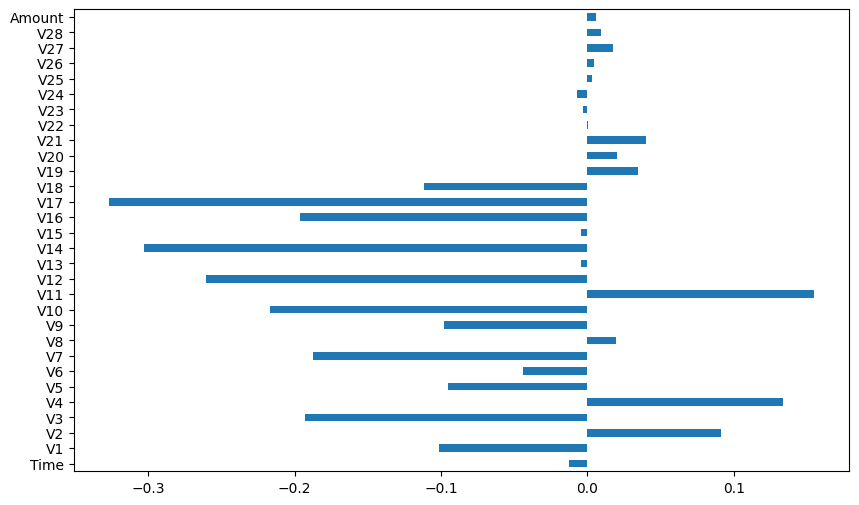

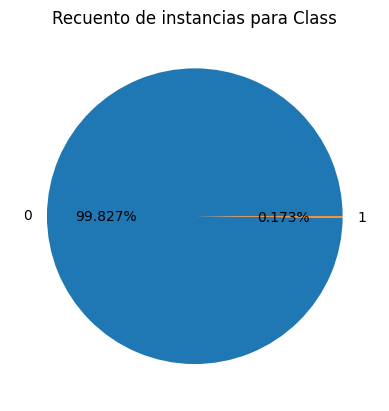

In [18]:
# Vemos correlaciones
correlaciones = raw_data.corr()['Class'].drop('Class')
correlaciones.plot(kind='barh', figsize=(10, 6))

# Recuento de instancias, primero definimos las opciones 
labels = [0,1]

# Hacemos recuento de opciones
sizes = raw_data.Class.value_counts().values

# plotteamos
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.3f%%')
ax.set_title('Recuento de instancias para Class')
plt.show()

Notemos que muchas de las variables en este dataset no tienen una gran correlación con nuestro target y que en simultaneo hay una gran diferencia en la cantidad de casos fradulentos vs legítimos, por lo tanto es importante prestar mas atención a estos pocos casos para el entrenamiento

## Preprocesamiento

Ahora normalicemos nuestro dataset y mantengamos algunos de los features mas relacionados, luego separemos en entrenamiento y validación

In [27]:
# Estandarizamos features
raw_data.iloc[:, 1:30] = StandardScaler().fit_transform(raw_data.iloc[:, 1:30])

#Nos quedamos con los 6 features mas pesados
heaviest_correlations = abs(raw_data.corr()['Class']).drop('Class')
heaviest_correlations = heaviest_correlations.sort_values(ascending=False)[:6].index.to_list()

# X: Features finales, 
X = raw_data[heaviest_correlations].values

# y: label vector
y = raw_data["Class"]

# normalizamos 
X = normalize(X, norm="l1")

# Validacion y Entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Creacion y Estudio de Modelo(s)

Ahora tenemos que armar nuestros dos modelos, SVM y Arbol de Decisión. <br> Sin embargo, como dijimos antes tenemos un muy pequeño grupo de informacion sobre los casos fraudulentos y por lo tanto es importante que nuestros pesos para el arbol de decision tengan esto en cuenta, por lo que debemos armarlo "manualmente" y de forma balanceada.

In [21]:
# Armamos peso manual
w_train = compute_sample_weight('balanced', y_train)

# Arbol de Decision
dt = DecisionTreeClassifier(max_depth=4, random_state=35)
# Entrenamiento del Arbol
dt.fit(X_train, y_train, sample_weight=w_train)

# SVM
svm = LinearSVC(class_weight='balanced', random_state=31, loss="hinge", fit_intercept=False)
# Entrenamiento del SVM
svm.fit(X_train, y_train)

LinearSVC(class_weight='balanced', fit_intercept=False, loss='hinge',
          random_state=31)

In [22]:

#Hacemos predicciones de nuestros modelos
y_pred_dt = dt.predict_proba(X_test)[:,1]
y_pred_svm = svm.decision_function(X_test)

roc_auc_dt = roc_auc_score(y_test, y_pred_dt)
print('Arbol de Decision ROC-AUC score : {0:.3f}'.format(roc_auc_dt))
roc_auc_svm = roc_auc_score(y_test, y_pred_svm)
print('SVM ROC-AUC score : {0:.3f}'.format(roc_auc_svm))

Arbol de Decision ROC-AUC score : 0.952
SVM ROC-AUC score : 0.937


## Conclusiones

En este caso, utilizamos un numero mas pequeño de features y por lo tanto nuestro SVM tuvo una peor performance que el arbol de decisión, pero como bien sabemos los SVM tienen un mejor desempeño a mayor cantidad de features (siempre y cuando sean valiosas). <br> Podriamos entonces rapidamente recalcular los modelos con todos los features y ver si efectivamente supera al arbol de decision

In [32]:
raw_data=pd.read_csv(url)
# Estandarizamos
raw_data.iloc[:, 1:30] = StandardScaler().fit_transform(raw_data.iloc[:, 1:30])
data_matrix = raw_data.values

# X: Nuestros features, sin excluir nada
X = data_matrix[:, 1:30]

# Y: Nuestro target
y = data_matrix[:, 30]

# Normalizamos
X = normalize(X, norm="l1")

#Separamos en entrenamiento y validacion
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)



In [ ]:
#Armamos arbol de decision
dt = DecisionTreeClassifier(max_depth=4, random_state=35)
#Entrenamos
dt.fit(X_train, y_train, sample_weight=w_train)

#Armamos SVM
svm = LinearSVC(class_weight='balanced', random_state=31, loss="hinge", fit_intercept=False)
#Entrenamos
svm.fit(X_train, y_train)

LinearSVC(class_weight='balanced', fit_intercept=False, loss='hinge',
          random_state=31)

In [ ]:
y_pred_dt = dt.predict_proba(X_test)[:,1]
y_pred_svm = svm.decision_function(X_test)

roc_auc_dt = roc_auc_score(y_test, y_pred_dt)
print('Arbol de Decision ROC-AUC score : {0:.3f}'.format(roc_auc_dt))
roc_auc_svm = roc_auc_score(y_test, y_pred_svm)
print("SVM ROC-AUC score: {0:.3f}".format(roc_auc_svm))

Decision Tree ROC-AUC score : 0.939
SVM ROC-AUC score: 0.986


Efectivamente, nuestro modelo SVM mejora muchisimo en performance si dejamos todas las features, incluso aquellas que quizas no estaban tan relacionadas con nuestro target!